In [1]:
# -------------------------
# 1. PILIH VARIABEL NUMERIK
# -------------------------

fitur = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_bidan',
    'jumlah_dokter',
    'jumlah_perawat',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penyakit_menular',
    'jumlah_penduduk'
]

# -------------------------
# 2. MinMax SCALING
# -------------------------

from sklearn.preprocessing import MinMaxScaler
import pandas as pd

df = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[fitur]),
    columns=fitur
)

# -------------------------
# 3. GABUNGKAN DENGAN KOLOM IDENTITAS
# -------------------------

df_minmax = pd.concat(
    [
        df[
            [
                'kode_provinsi',
                'nama_provinsi',
                'kode_kabupaten_kota',
                'nama_kabupaten_kota',
                'tahun'
            ]
        ].reset_index(drop=True),

        df_scaled.reset_index(drop=True)
    ],
    axis=1
)

# -------------------------
# 4. CEK HASIL
# -------------------------

print("Rata-rata setelah standarisasi:")
print(df_scaled.mean())

print("\nStandar deviasi setelah standarisasi:")
print(df_scaled.std())

display(df_minmax.head())

Rata-rata setelah standarisasi:
pelayanan_non_rawat_inap         0.232166
pelayanan_rawat_inap             0.371831
jumlah_bidan                     0.307700
jumlah_dokter                    0.040262
jumlah_perawat                   0.108134
jumlah_penyakit_tidak_menular    0.161744
jumlah_penyakit_menular          0.038530
jumlah_penduduk                  0.328080
dtype: float64

Standar deviasi setelah standarisasi:
pelayanan_non_rawat_inap         0.233388
pelayanan_rawat_inap             0.227703
jumlah_bidan                     0.211131
jumlah_dokter                    0.086742
jumlah_perawat                   0.127662
jumlah_penyakit_tidak_menular    0.176561
jumlah_penyakit_menular          0.083328
jumlah_penduduk                  0.231362
dtype: float64


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016


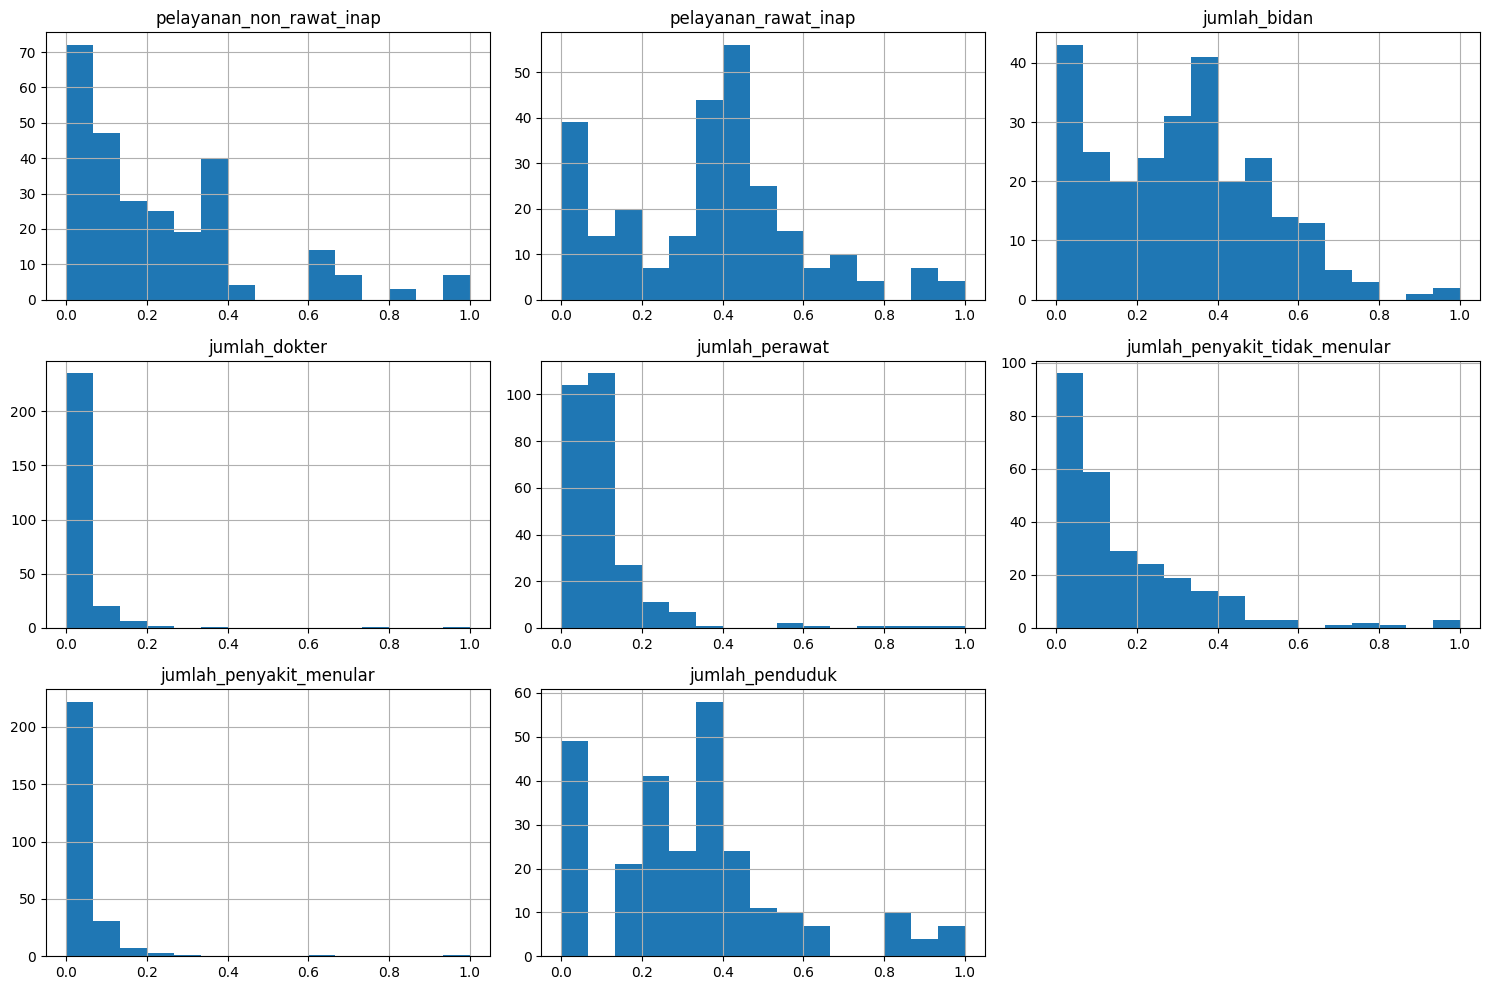

In [4]:
import matplotlib.pyplot as plt

df_scaled.hist(
    figsize=(15,10),
    bins=15
)

plt.tight_layout()
plt.show()

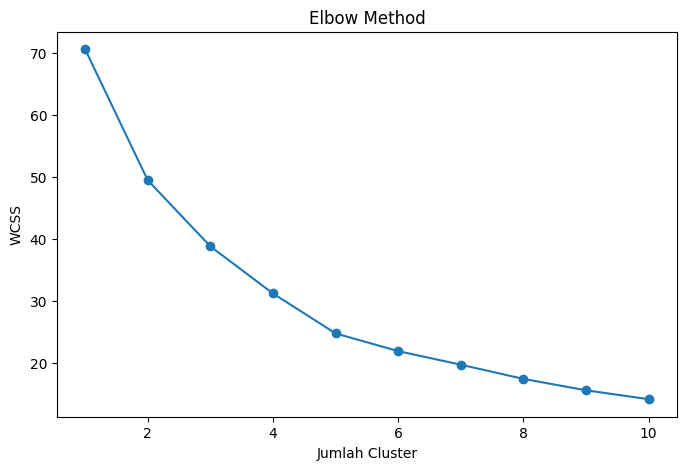

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [6]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

hasil = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)

    hasil.append([k, score])

hasil = pd.DataFrame(
    hasil,
    columns=['Jumlah Cluster', 'Silhouette Score']
)

display(hasil)

,Jumlah Cluster,Silhouette Score
0,2,0.346092
1,3,0.306047
2,4,0.317128
3,5,0.349259
4,6,0.308083
5,7,0.363998
6,8,0.329136
7,9,0.332864
8,10,0.340389


In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_hasil = df_scaled.copy()
df_hasil['cluster'] = kmeans.fit_predict(df_scaled)

In [8]:
df_hasil['cluster'].value_counts().sort_index()

cluster
0     68
1     58
2    132
3      8
Name: count, dtype: int64

In [9]:
profil_cluster = (
    df_hasil
    .groupby('cluster')
    [
        [
            'pelayanan_non_rawat_inap',
            'pelayanan_rawat_inap',
            'jumlah_bidan',
            'jumlah_dokter',
            'jumlah_perawat',
            'jumlah_penyakit_tidak_menular',
            'jumlah_penyakit_menular',
            'jumlah_penduduk'
        ]
    ]
    .mean()
    .round(2)
)

display(profil_cluster)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,
0,0.16,0.10,0.13,0.02,0.06,0.05,0.02,0.07
1,0.50,0.31,0.44,0.06,0.14,0.22,0.05,0.48
2,0.12,0.53,0.32,0.03,0.08,0.16,0.03,0.35
3,0.87,0.56,0.70,0.29,0.70,0.72,0.25,0.97


In [10]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

silhouette = silhouette_score(
    df_scaled,
    df_hasil['cluster']
)

dbi = davies_bouldin_score(
    df_scaled,
    df_hasil['cluster']
)

chi = calinski_harabasz_score(
    df_scaled,
    df_hasil['cluster']
)

print("=== Evaluasi K-Means ===")
print(f"Silhouette Score      : {silhouette:.4f}")
print(f"Davies-Bouldin Index  : {dbi:.4f}")
print(f"Calinski-Harabasz     : {chi:.4f}")

=== Evaluasi K-Means ===
Silhouette Score      : 0.3171
Davies-Bouldin Index  : 1.1452
Calinski-Harabasz     : 110.2987


In [11]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

cluster_agglo = agglo.fit_predict(df_scaled)

df_agglo = df_scaled.copy()
df_agglo['cluster'] = cluster_agglo

df_agglo.head()

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster
0,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688,0
1,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919,1
2,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696,0
3,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123,1
4,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016,0


In [12]:
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd

# Evaluasi
silhouette = silhouette_score(df_scaled, cluster_agglo)
dbi = davies_bouldin_score(df_scaled, cluster_agglo)
chi = calinski_harabasz_score(df_scaled, cluster_agglo)

# Tabel hasil evaluasi
hasil_evaluasi = pd.DataFrame({
    'Metode': ['Agglomerative Hierarchical Clustering'],
    'Silhouette Coefficient': [round(silhouette, 4)],
    'Davies-Bouldin Index': [round(dbi, 4)],
    'Calinski-Harabasz Index': [round(chi, 4)]
})

display(hasil_evaluasi)

,Metode,Silhouette Coefficient,Davies-Bouldin Index,Calinski-Harabasz Index
0,Agglomerative Hierarchical Clustering,0.3034,1.1541,105.3373


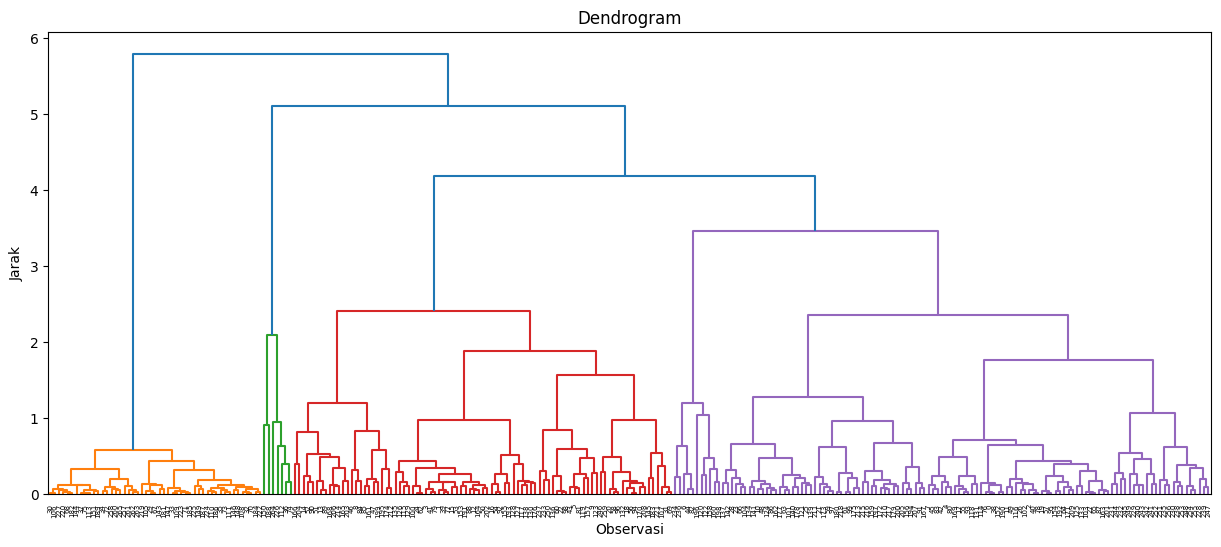

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(
    df_scaled,
    method='ward'
)

plt.figure(figsize=(15,6))

dendrogram(Z)

plt.title('Dendrogram')
plt.xlabel('Observasi')
plt.ylabel('Jarak')
plt.show()

In [14]:
profil_agglo = (
    df_agglo
    .groupby('cluster')
    [
        [
            'pelayanan_non_rawat_inap',
            'pelayanan_rawat_inap',
            'jumlah_bidan',
            'jumlah_dokter',
            'jumlah_perawat',
            'jumlah_penyakit_tidak_menular',
            'jumlah_penyakit_menular',
            'jumlah_penduduk'
        ]
    ]
    .mean()
    .round(2)
)

display(profil_agglo)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster,,,,,,,,
0,0.10,0.53,0.3,0.02,0.08,0.18,0.03,0.35
1,0.44,0.33,0.4,0.05,0.13,0.17,0.05,0.41
2,1.00,0.51,0.7,0.33,0.76,0.69,0.29,0.98
3,0.10,0.04,0.1,0.02,0.05,0.03,0.01,0.02


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd

hasil_evaluasi = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_scaled)

    silhouette = silhouette_score(df_scaled, labels)
    dbi = davies_bouldin_score(df_scaled, labels)
    chi = calinski_harabasz_score(df_scaled, labels)

    hasil_evaluasi.append([
        k,
        round(silhouette, 4),
        round(dbi, 4),
        round(chi, 4)
    ])

hasil_evaluasi = pd.DataFrame(
    hasil_evaluasi,
    columns=[
        'Jumlah Cluster',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index'
    ]
)

display(hasil_evaluasi)

,Jumlah Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.3461,1.3546,112.7845
1,3,0.3060,1.2100,107.7721
2,4,0.3171,1.1452,110.2987
3,5,0.3493,1.0386,120.8471
4,6,0.3081,1.1099,115.6933
5,7,0.3640,1.1120,111.4856
6,8,0.3291,1.0398,112.5626
7,9,0.3329,1.0305,113.5031
8,10,0.3404,1.0319,113.6159


In [16]:
print("Cluster terbaik berdasarkan Silhouette:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Silhouette Score'].idxmax()
    ]
)

print("\nCluster terbaik berdasarkan DBI:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Davies-Bouldin Index'].idxmin()
    ]
)

print("\nCluster terbaik berdasarkan CHI:")
display(
    hasil_evaluasi.loc[
        hasil_evaluasi['Calinski-Harabasz Index'].idxmax()
    ]
)

Cluster terbaik berdasarkan Silhouette:


Jumlah Cluster               7.0000
Silhouette Score             0.3640
Davies-Bouldin Index         1.1120
Calinski-Harabasz Index    111.4856
Name: 5, dtype: float64


Cluster terbaik berdasarkan DBI:


Jumlah Cluster               9.0000
Silhouette Score             0.3329
Davies-Bouldin Index         1.0305
Calinski-Harabasz Index    113.5031
Name: 7, dtype: float64


Cluster terbaik berdasarkan CHI:


Jumlah Cluster               5.0000
Silhouette Score             0.3493
Davies-Bouldin Index         1.0386
Calinski-Harabasz Index    120.8471
Name: 3, dtype: float64